# 04i — Isentropic Single-Variable Composite Explorer

Like `04_single_var_composite.ipynb` but on **isentropic surfaces**
(315–355 K in 5 K steps).

For each NPZ event the 3-D isobaric fields are **interpolated onto θ**
before compositing, so the bootstrap CI operates on per-event isentropic
slices.

**Two modes**:
1. **2-panel** (default): composite mean + bootstrap significance (hatched non-sig)
2. **6-panel** (`projection=True`): adds 2×2 projection onto dh−1 orthogonal
   basis (INT, PRP, DEF, Residual) using **only significant** grid points.

Data: `/net/flood/data2/users/x_yan/composite_blocking_tempest/onset`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os, glob
from concurrent.futures import ThreadPoolExecutor

from pvtend import compute_orthogonal_basis, project_field
from pvtend.decomposition.smoothing import gaussian_smooth_nan
from pvtend.isentropic import interp_event_field_to_single_theta

## 1  Configuration & available fields

In [2]:
DATA_ROOT  = "/net/flood/data2/users/x_yan/composite_blocking_tempest"
STAGE      = "onset"
SMOOTH_DEG = 3.0
GRID_SP    = 1.5
N_BOOT     = 1000
ALPHA      = 0.05
SEED       = 42
PV_CONTOUR = - 0 * 0.5e-6     # PV anomaly contour for mask boundary
N_CONTOUR  = 21          # number of contourf levels

# ═══════════════════════════════════════════════════════════
#  Projection masking config (toggle on/off)
# ═══════════════════════════════════════════════════════════
USE_SIG_MASK    = True   # zero out non-significant pixels before projection
USE_NEG_PV_MASK = True   # restrict basis to q' < 0 region (mask_negative)

# ── Isentropic target levels (K) ──
THETA_LEVELS = np.arange(315, 360, 5, dtype=float)  # 315, 320, … 355 K

# ── Discover available 3-D fields from a sample NPZ ──
_sample = np.load(f"{DATA_ROOT}/{STAGE}/dh=+0/" +
                  sorted(os.listdir(f"{DATA_ROOT}/{STAGE}/dh=+0"))[0])
levels_hpa = _sample["levels"]
fields_3d  = sorted(k for k in _sample.keys() if k.endswith("_3d"))

print(f"Isobaric levels (hPa): {levels_hpa}")
print(f"Target θ levels  (K) : {THETA_LEVELS}")
print(f"\n── 3-D isobaric fields ({len(fields_3d)}) ──")
for f in fields_3d:
    print(f"  {f}")

# Sanity-check θ range in the sample event
th = _sample["theta_3d"]
print(f"\n── Sample-event θ range per level ──")
for i, lev in enumerate(levels_hpa):
    print(f"  {lev:5d} hPa → θ = {np.nanmin(th[i]):.1f} – {np.nanmax(th[i]):.1f} K")

print(f"\n  USE_SIG_MASK={USE_SIG_MASK}  USE_NEG_PV_MASK={USE_NEG_PV_MASK}")

del _sample, th

Isobaric levels (hPa): [1000  850  700  500  400  300  250  200  100]
Target θ levels  (K) : [315. 320. 325. 330. 335. 340. 345. 350. 355.]

── 3-D isobaric fields (78) ──
  Q_3d
  pv_3d
  pv_anom_3d
  pv_anom_dp_3d
  pv_anom_dt_3d
  pv_anom_dx_3d
  pv_anom_dy_3d
  pv_bar_3d
  pv_bar_dp_3d
  pv_bar_dt_3d
  pv_bar_dx_3d
  pv_bar_dy_3d
  pv_dp_3d
  pv_dt_3d
  pv_dx_3d
  pv_dy_3d
  t_3d
  theta_3d
  theta_dot_3d
  theta_dt_3d
  u_3d
  u_anom_3d
  u_anom_div_3d
  u_anom_har_3d
  u_anom_pv_anom_dx_3d
  u_anom_pv_bar_dx_3d
  u_anom_rot_3d
  u_bar_3d
  u_bar_pv_anom_dx_3d
  u_bar_pv_bar_dx_3d
  u_div_dry_3d
  u_div_dry_pv_anom_dx_3d
  u_div_dry_pv_bar_dx_3d
  u_div_moist_3d
  u_div_moist_pv_anom_dx_3d
  u_div_moist_pv_bar_dx_3d
  u_div_pv_anom_dx_3d
  u_div_pv_bar_dx_3d
  u_har_pv_anom_dx_3d
  u_har_pv_bar_dx_3d
  u_rot_pv_anom_dx_3d
  u_rot_pv_bar_dx_3d
  v_3d
  v_anom_3d
  v_anom_div_3d
  v_anom_har_3d
  v_anom_pv_anom_dy_3d
  v_anom_pv_bar_dy_3d
  v_anom_rot_3d
  v_bar_3d
  v_bar_pv_anom_d

## Isentropic interpolation — MetPy-aligned algorithm

Each NPZ event contains 3-D fields on $N_p$ isobaric levels
$\{p_1, p_2, \dots, p_{N_p}\}$ (here 1000, 850, 700, 500, 400, 300, 250, 200, 100 hPa).
The potential-temperature field $\theta(p)$ is also stored at every grid column
$(j, i)$.

**Goal.** Given a target isentropic level $\theta^*$ (e.g. 330 K), obtain
$\phi(\theta^*)$ for any 3-D field $\phi$ at every horizontal grid point.

### What is needed

| Quantity | Symbol | Shape | Units |
|---|---|---|---|
| Pressure levels | $p_k$ | $(N_p,)$ | hPa |
| Temperature | $T(p_k, j, i)$ | $(N_p, N_y, N_x)$ | K |
| Potential temperature | $\theta = T(P_0/p)^\kappa$ | $(N_p, N_y, N_x)$ | K |
| Target isentropic surfaces | $\theta^*$ | $(N_\theta,)$ | K |
| Field to interpolate | $\phi(p_k, j, i)$ | $(N_p, N_y, N_x)$ | various |

### Algorithm (Ziv & Alpert 1994, as in MetPy `isentropic_interpolation`)

The implementation in `pvtend.isentropic` follows MetPy v1.7 ([source](https://github.com/Unidata/MetPy/blob/v1.7.1/src/metpy/calc/thermo.py#L3023-L3190)):

1. **Sort** pressure levels in descending order (surface → top).

2. **Compute** potential temperature at every grid point:
$$\theta = T \left(\frac{P_0}{p}\right)^\kappa, \quad \kappa = R_d / c_{pd} \approx 0.286$$

3. For each target $\theta^*$, **find bounding indices** $m, m+1$ such that
   $\theta_m \leq \theta^* \leq \theta_{m+1}$.

4. **Assume** temperature varies linearly with $\ln p$ between the bounding levels:
$$T(\ln p) = a \cdot \ln p + b$$
where:
$$a = \frac{T_{m+1} - T_m}{\ln p_{m+1} - \ln p_m}, \quad
b = T_{m+1} - a \cdot \ln p_{m+1}$$

5. **Newton-Raphson** iteration to solve for $p^*$ on the $\theta^*$ surface:
$$\theta^* = T(\ln p) \cdot \left(\frac{P_0}{p}\right)^\kappa
  = (a \ln p + b) \cdot P_0^\kappa \cdot e^{-\kappa \ln p}$$

   Define:
$$f(\ln p) = \theta^* - (a \ln p + b) \cdot P_0^\kappa \cdot e^{-\kappa \ln p}$$
$$f'(\ln p) = P_0^\kappa \cdot e^{-\kappa \ln p} \cdot (\kappa T - a)$$

   Update:
$$\ln p_{n+1} = \ln p_n - \frac{f}{f'}$$

6. Once $p^*$ is known, **interpolate** additional fields linearly onto the
   isentropic surface (column-wise `np.interp` against sorted $\theta$).

If $\theta^*$ is **outside** the column's $\theta$ range → NaN (no extrapolation).

### Why this is better than simple θ-interpolation

- The Newton-Raphson approach correctly models the **non-linear Poisson relationship** between $T$ and $p$, rather than assuming $\phi$ varies linearly with $\theta$.
- Additional fields are interpolated via $\theta$ as the vertical coordinate, which is meteorologically consistent.

### Reference
Ziv, B. & Alpert, P. (1994). *Beitr. Phys. Atmosph.*, 67, 221–230.
MetPy docs: [isentropic_interpolation](https://unidata.github.io/MetPy/latest/api/generated/metpy.calc.isentropic_interpolation.html)

## 2  Core helpers

In [3]:
from zipfile import BadZipFile


def _load_npz(path):
    try:
        return dict(np.load(path))
    except (BadZipFile, EOFError, OSError):
        return None


def load_events(dh, stage=STAGE):
    """Load all events at a given dh → list[dict] (skips bad files)."""
    sign = "+" if dh >= 0 else ""
    d = f"{DATA_ROOT}/{stage}/dh={sign}{dh}"
    files = sorted(glob.glob(os.path.join(d, "track_*.npz")))
    if not files:
        return []
    with ThreadPoolExecutor(max_workers=8) as pool:
        results = list(pool.map(_load_npz, files))
    good = [r for r in results if r is not None]
    n_bad = len(results) - len(good)
    if n_bad:
        print(f"  ⚠ dh={dh}: skipped {n_bad} corrupt/incomplete NPZ files")
    return good


# ─────────────────────────────────────────────────────
# Isentropic field extraction (using pvtend.isentropic)
# ─────────────────────────────────────────────────────
def get_field_isen(event, var_spec, theta_level):
    """Extract a 2-D isentropic field from one event.

    Uses ``pvtend.isentropic.interp_event_field_to_single_theta``
    which follows the MetPy / Ziv-Alpert (1994) algorithm:
      - column-wise interpolation with θ sorted ascending
      - NaN for out-of-range θ* (no extrapolation)

    Parameters
    ----------
    event : dict — loaded NPZ event.
    var_spec : str or list[str]
        Field name(s) with optional '-' prefix for negation.  Summed.
        '_3d' suffix is appended automatically.
    theta_level : float (K)

    Returns
    -------
    (ny, nx) array.
    """
    if isinstance(var_spec, str):
        var_spec = [var_spec]

    theta_3d = event["theta_3d"]   # (nlev, ny, nx)

    total = None
    for vs in var_spec:
        negate = vs.startswith("-")
        name = vs.lstrip("-").strip()
        key_3d = name if name.endswith("_3d") else name + "_3d"

        # Interpolate using the MetPy-aligned pvtend function
        arr = interp_event_field_to_single_theta(
            theta_3d, event[key_3d], theta_level)

        if negate:
            arr = -arr
        total = arr.copy() if total is None else total + arr
    return total


def bootstrap_sig_isen(events, var_spec, theta_level,
                       n_boot=N_BOOT, alpha=ALPHA, seed=SEED):
    """Composite mean + bootstrap CI on an isentropic surface.

    Returns (mean_2d, sig_mask) — sig_mask=True where CI excludes zero.
    """
    print(f"  Interpolating {len(events)} events to θ={theta_level} K ...")
    stack = np.array([get_field_isen(e, var_spec, theta_level) for e in events])
    N = stack.shape[0]
    rng = np.random.default_rng(seed)

    boot = np.empty((n_boot, *stack.shape[1:]))
    for b in range(n_boot):
        idx = rng.integers(0, N, size=N)
        boot[b] = np.nanmean(stack[idx], axis=0)

    lo = np.nanpercentile(boot, 100 * alpha / 2, axis=0)
    hi = np.nanpercentile(boot, 100 * (1 - alpha / 2), axis=0)
    mean = np.nanmean(stack, axis=0)
    sig_mask = ~((lo <= 0) & (hi >= 0))
    return mean, sig_mask


print("Helpers defined (using pvtend.isentropic).")

Helpers defined (using pvtend.isentropic).


## 2b  Sanity check — 3-D θ structure & isentropic interpolation

Event shape: (9, 29, 49)  (nlev=9, ny=29, nx=49)
Pressure levels: [1000  850  700  500  400  300  250  200  100]


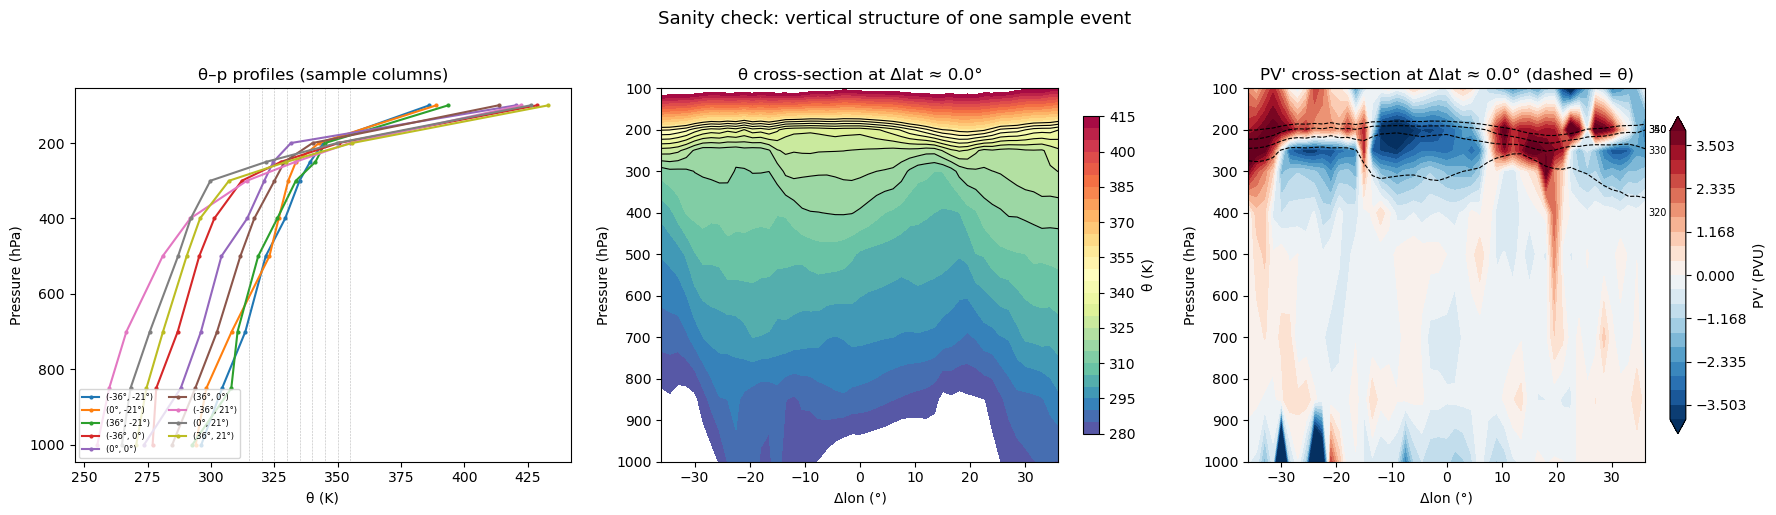

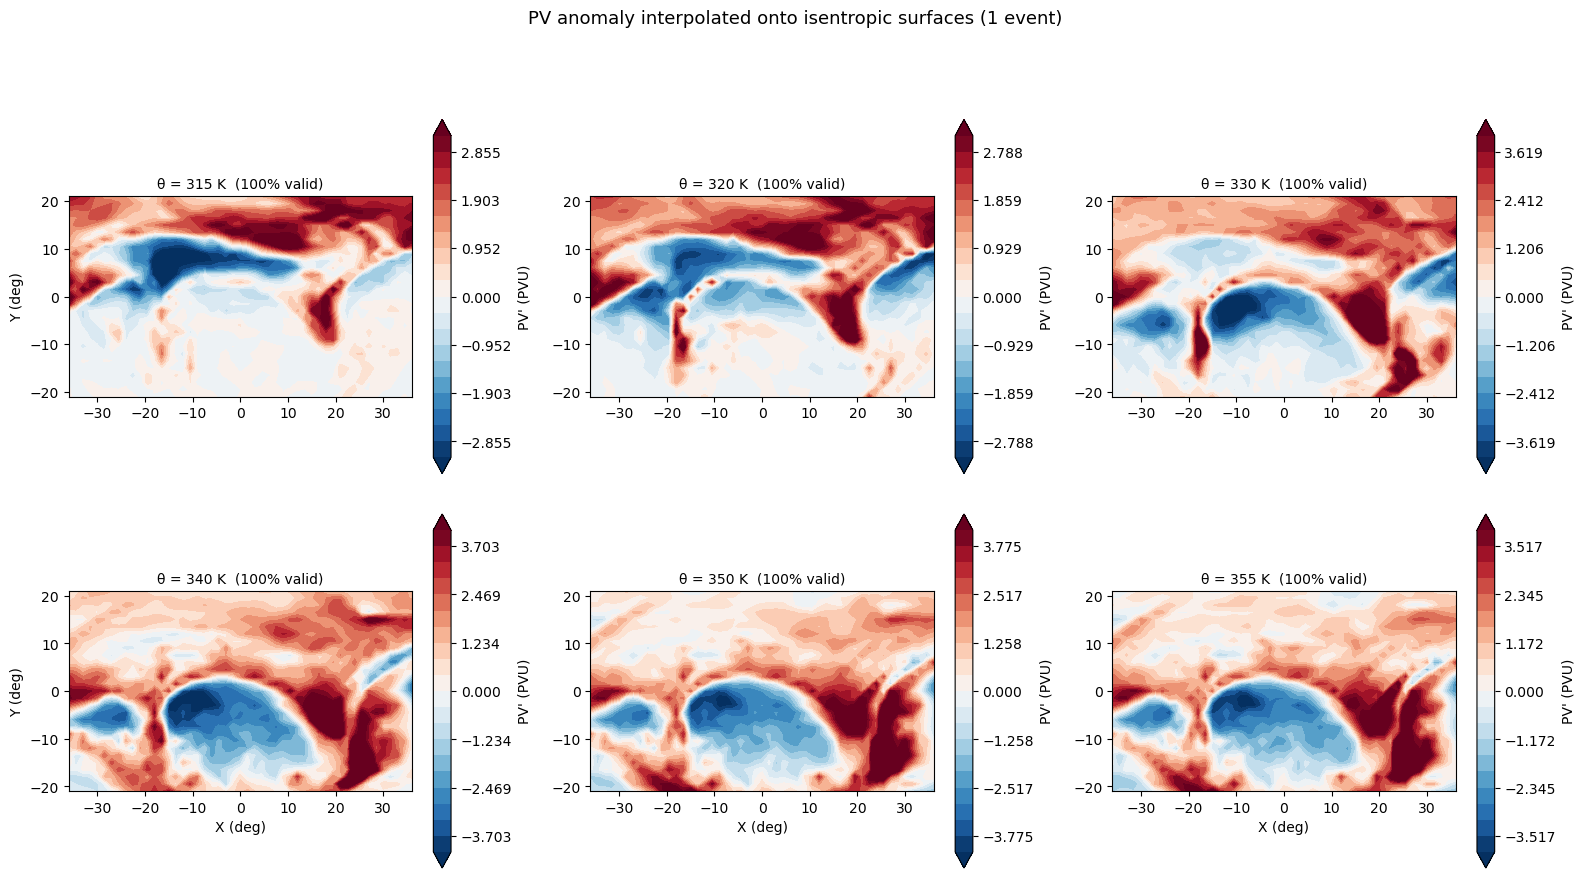

Sanity check complete.


In [4]:
# ── Load one sample event for visualization ──────────────────────────
_ev = load_events(dh=0)[0]
theta_3d = _ev["theta_3d"]          # (nlev, ny, nx)
pv_3d    = _ev["pv_anom_3d"]        # (nlev, ny, nx)
X_rel    = _ev["X_rel"]
Y_rel    = _ev["Y_rel"]
x_rel    = X_rel[0, :]
y_rel    = Y_rel[:, 0]
nlev, ny, nx = theta_3d.shape

print(f"Event shape: {theta_3d.shape}  (nlev={nlev}, ny={ny}, nx={nx})")
print(f"Pressure levels: {levels_hpa}")

# ── Panel 1: θ(p) profiles at 9 grid points (3×3 sub-grid) ──────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) θ–p profiles at selected columns
ax = axes[0]
jj = np.linspace(0, ny - 1, 3, dtype=int)
ii = np.linspace(0, nx - 1, 3, dtype=int)
for j in jj:
    for i in ii:
        th_col = theta_3d[:, j, i]
        ax.plot(th_col, levels_hpa, marker=".", ms=4,
                label=f"({x_rel[i]:.0f}°, {y_rel[j]:.0f}°)")
# Overlay target θ levels as horizontal bands
for tl in THETA_LEVELS:
    ax.axvline(tl, color="grey", lw=0.4, ls=":")
ax.set_xlabel("θ (K)")
ax.set_ylabel("Pressure (hPa)")
ax.invert_yaxis()
ax.set_title("θ–p profiles (sample columns)")
ax.legend(fontsize=6, ncol=2, loc="lower left")

# (b) Cross-section: θ along the central latitude (y_rel ≈ 0)
ax = axes[1]
j_mid = ny // 2
th_slice = theta_3d[:, j_mid, :]   # (nlev, nx)
cf = ax.contourf(x_rel, levels_hpa, th_slice,
                 levels=np.arange(280, 420, 5), cmap="Spectral_r")
for tl in THETA_LEVELS:
    ax.contour(x_rel, levels_hpa, th_slice, levels=[tl],
               colors="k", linewidths=0.8)
ax.invert_yaxis()
ax.set_xlabel("Δlon (°)")
ax.set_ylabel("Pressure (hPa)")
ax.set_title(f"θ cross-section at Δlat ≈ {y_rel[j_mid]:.1f}°")
plt.colorbar(cf, ax=ax, label="θ (K)", shrink=0.85)

# (c) Cross-section: PV anomaly along central latitude
ax = axes[2]
pv_slice = pv_3d[:, j_mid, :] * 1e6  # → PVU
vmax_pv = np.nanpercentile(np.abs(pv_slice), 95)
cf2 = ax.contourf(x_rel, levels_hpa, pv_slice,
                  levels=np.linspace(-vmax_pv, vmax_pv, 21),
                  cmap="RdBu_r", extend="both")
for tl in [320, 330, 340, 350]:
    ax.contour(x_rel, levels_hpa, th_slice, levels=[tl],
               colors="k", linewidths=0.8, linestyles="--")
    # Label the θ contour
    ax.text(x_rel[-1] + 0.5, levels_hpa[np.argmin(np.abs(th_slice[:, -1] - tl))],
            f"{tl}", fontsize=7, va="center")
ax.invert_yaxis()
ax.set_xlabel("Δlon (°)")
ax.set_ylabel("Pressure (hPa)")
ax.set_title(f"PV' cross-section at Δlat ≈ {y_rel[j_mid]:.1f}° (dashed = θ)")
plt.colorbar(cf2, ax=ax, label="PV' (PVU)", shrink=0.85)

fig.suptitle("Sanity check: vertical structure of one sample event", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

# ── Panel 2: PV anomaly interpolated onto multiple θ surfaces ────────
theta_show = [315, 320, 330, 340, 350, 355]
n_th = len(theta_show)
fig2, axes2 = plt.subplots(2, 3, figsize=(16, 9))

for idx, tl in enumerate(theta_show):
    ax = axes2.flat[idx]
    pv_isen = get_field_isen(_ev, "pv_anom", tl)
    valid_frac = 100 * np.mean(np.isfinite(pv_isen))
    pv_isen_pvu = pv_isen * 1e6
    vmax_i = np.nanpercentile(np.abs(pv_isen_pvu[np.isfinite(pv_isen_pvu)]), 95) \
             if np.any(np.isfinite(pv_isen_pvu)) else 1.0
    vmax_i = max(vmax_i, 1e-6)
    im = ax.contourf(X_rel, Y_rel, pv_isen_pvu,
                     levels=np.linspace(-vmax_i, vmax_i, 21),
                     cmap="RdBu_r", extend="both")
    ax.set_title(f"θ = {tl} K  ({valid_frac:.0f}% valid)", fontsize=10)
    ax.set_aspect("equal")
    if idx % 3 == 0:
        ax.set_ylabel("Y (deg)")
    if idx >= 3:
        ax.set_xlabel("X (deg)")
    plt.colorbar(im, ax=ax, shrink=0.8, label="PV' (PVU)")

fig2.suptitle("PV anomaly interpolated onto isentropic surfaces (1 event)",
              fontsize=13, y=1.02)
fig2.tight_layout()
plt.show()

del _ev
print("Sanity check complete.")

## 3  Main plotting function

In [5]:
smooth = lambda f: gaussian_smooth_nan(f, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP)


def plot_var(var_spec, dh=0, theta_level=330.0, projection=False,
             n_boot=N_BOOT, alpha=ALPHA, seed=SEED, figsize_scale=1.0):
    """Composite + bootstrap plot on an isentropic surface.

    Parameters
    ----------
    var_spec : str or list[str]
        Field name(s) with optional '-' prefix for negation.  Summed.
    dh : int
        Lifecycle hour.
    theta_level : float
        Isentropic level (K).
    projection : bool
        If True, add 2×2 projection rows (3-row / 6-panel figure).
    """
    if isinstance(var_spec, str):
        var_spec = [var_spec]

    # ── 1. Load events ──
    evs = load_events(dh)
    N = len(evs)
    if N == 0:
        print(f"No events at dh={dh}")
        return
    X_rel = evs[0]["X_rel"]
    Y_rel = evs[0]["Y_rel"]
    x_rel = X_rel[0, :]
    y_rel = Y_rel[:, 0]

    # ── 2. Composite mean + bootstrap on θ surface ──
    print(f"Computing bootstrap (N={N}, n_boot={n_boot}, θ={theta_level} K) ...")
    mean_fld, sig_mask = bootstrap_sig_isen(evs, var_spec, theta_level,
                                            n_boot, alpha, seed)
    pct_sig = 100 * np.nanmean(sig_mask)
    print(f"  {pct_sig:.1f}% significant at {100*(1-alpha):.0f}%")

    # PV anomaly composite on the same θ surface (for contour)
    pv_anom_mean = np.nanmean(
        [get_field_isen(e, "pv_anom", theta_level) for e in evs], axis=0)

    # ── Label ──
    var_label = " + ".join(var_spec)

    # ── 3. Projection (if requested) ──
    proj = None
    if projection:
        dh_basis = max(dh - 1, -13)
        evs_b = load_events(dh_basis) if dh_basis != dh else evs

        # Basis fields on the same θ surface from dh−1 composite mean
        pv_b = np.nanmean(
            [get_field_isen(e, "pv_anom", theta_level) for e in evs_b], axis=0)
        dx_b = np.nanmean(
            [get_field_isen(e, "pv_anom_dx", theta_level) for e in evs_b], axis=0)
        dy_b = np.nanmean(
            [get_field_isen(e, "pv_anom_dy", theta_level) for e in evs_b], axis=0)

        basis = compute_orthogonal_basis(
            pv_b, dx_b, dy_b, x_rel, y_rel,
            mask_negative=USE_NEG_PV_MASK,
            apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP,
        )

        # Project (optionally sig-only) field
        if USE_SIG_MASK:
            field_sig = np.where(sig_mask, mean_fld, 0.0)
        else:
            field_sig = mean_fld.copy()
        field_sig_s = smooth(field_sig)
        proj = project_field(field_sig_s, basis)
        print(f"  Projection (sig_mask={USE_SIG_MASK}): "
              f"β={proj['beta']:.3e}  αx={proj['ax']:.3f}  "
              f"αy={proj['ay']:.3f}  γ={proj['gamma']:.3e}")

    # ── 4. Plot ──
    n_rows = 3 if projection else 1
    fig = plt.figure(figsize=(14 * figsize_scale, 5 * n_rows * figsize_scale))
    gs = GridSpec(n_rows, 2, figure=fig, hspace=0.35, wspace=0.25)

    # Colour scale
    finite = mean_fld[np.isfinite(mean_fld)]
    if finite.size == 0:
        print("⚠ No finite values — θ level may be out of range for most events.")
        return None
    vmax = float(np.nanpercentile(np.abs(finite), 95))
    vmax = max(vmax, 1e-30)
    clevels = np.linspace(-vmax, vmax, N_CONTOUR)

    # --- Row 1, Left: Composite mean ---
    ax0 = fig.add_subplot(gs[0, 0])
    im0 = ax0.contourf(X_rel, Y_rel, mean_fld, levels=clevels,
                        cmap="RdBu_r", extend="both")
    ax0.contour(X_rel, Y_rel, pv_anom_mean,
                levels=[PV_CONTOUR], colors="white", linewidths=2.5)
    ax0.set_title(f"Composite Mean  (N={N})", fontsize=11, fontweight="bold")
    ax0.set_ylabel("Y (deg)"); ax0.set_xlabel("X (deg)")
    ax0.set_aspect("equal")
    plt.colorbar(im0, ax=ax0, shrink=0.85)

    # --- Row 1, Right: Bootstrap significance ---
    ax1 = fig.add_subplot(gs[0, 1])
    im1 = ax1.contourf(X_rel, Y_rel, mean_fld, levels=clevels,
                        cmap="RdBu_r", extend="both")
    ax1.contour(X_rel, Y_rel, pv_anom_mean,
                levels=[PV_CONTOUR], colors="white", linewidths=2.5)
    ax1.contourf(X_rel, Y_rel, (~sig_mask).astype(float),
                 levels=[0.5, 1.5], hatches=["xxx"], colors="none", zorder=5)
    ax1.set_title(f"Bootstrap sig ({100*(1-alpha):.0f}%)  "
                  f"Hatch=n.s.  ({pct_sig:.0f}% sig)",
                  fontsize=11, fontweight="bold")
    ax1.set_xlabel("X (deg)")
    ax1.set_aspect("equal")
    plt.colorbar(im1, ax=ax1, shrink=0.85)

    # --- Rows 2-3: Projection (2×2) ---
    if projection and proj is not None:
        panels = [
            ("INT (β · Φ₁)",           proj["int"]),
            ("PRP (αx·Φ₂ + αy·Φ₃)",   proj["prop"]),
            ("DEF (γ · Φ₄)",           proj["def"]),
            ("Residual",               proj["resid"]),
        ]
        all_abs = np.concatenate([
            np.abs(p[np.isfinite(p)]) for _, p in panels if np.any(np.isfinite(p))
        ])
        vmax_p = float(np.percentile(all_abs, 95)) if all_abs.size else 1e-30
        vmax_p = max(vmax_p, 1e-30)
        clev_p = np.linspace(-vmax_p, vmax_p, N_CONTOUR)

        coef_txt = (f"β={proj['beta']:.3e} s⁻¹   "
                    f"αx={proj['ax']:.3f} m/s   "
                    f"αy={proj['ay']:.3f} m/s   "
                    f"γ={proj['gamma']:.3e} s⁻¹   "
                    f"RMSE/max={proj['rmse']/(np.nanmax(np.abs(mean_fld))+1e-30):.3f}")

        for idx, (label, field) in enumerate(panels):
            row = 1 + idx // 2
            col = idx % 2
            ax = fig.add_subplot(gs[row, col])
            im = ax.contourf(X_rel, Y_rel, field, levels=clev_p,
                             cmap="RdBu_r", extend="both")
            ax.contour(X_rel, Y_rel, pv_anom_mean,
                       levels=[PV_CONTOUR], colors="white", linewidths=2.0)
            ax.set_title(label, fontsize=10, fontweight="bold")
            ax.set_xlabel("X (deg)")
            if col == 0:
                ax.set_ylabel("Y (deg)")
            ax.set_aspect("equal")
            plt.colorbar(im, ax=ax, shrink=0.75)

        fig.text(0.5, 1 - 1.0 / n_rows - 0.01, coef_txt,
                 ha="center", fontsize=10, fontstyle="italic",
                 transform=fig.transFigure)

    sign_str = "+" if dh >= 0 else ""
    fig.suptitle(
        f"{STAGE}  dh={sign_str}{dh}   θ={theta_level:.0f} K   N={N}\n"
        f"Field: {var_label}",
        fontsize=12, fontweight="bold", y=1.02,
    )
    fig.tight_layout()
    plt.show()
    return proj


print("plot_var() defined.")

plot_var() defined.


## 4  Examples

Computing bootstrap (N=1260, n_boot=1000, θ=330 K) ...
  Interpolating 1260 events to θ=330 K ...
  76.7% significant at 95%
  Projection (sig_mask=True): β=9.083e-07  αx=-0.729  αy=0.091  γ=-1.007e+05


/tmp/ipykernel_2266529/2997814579.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


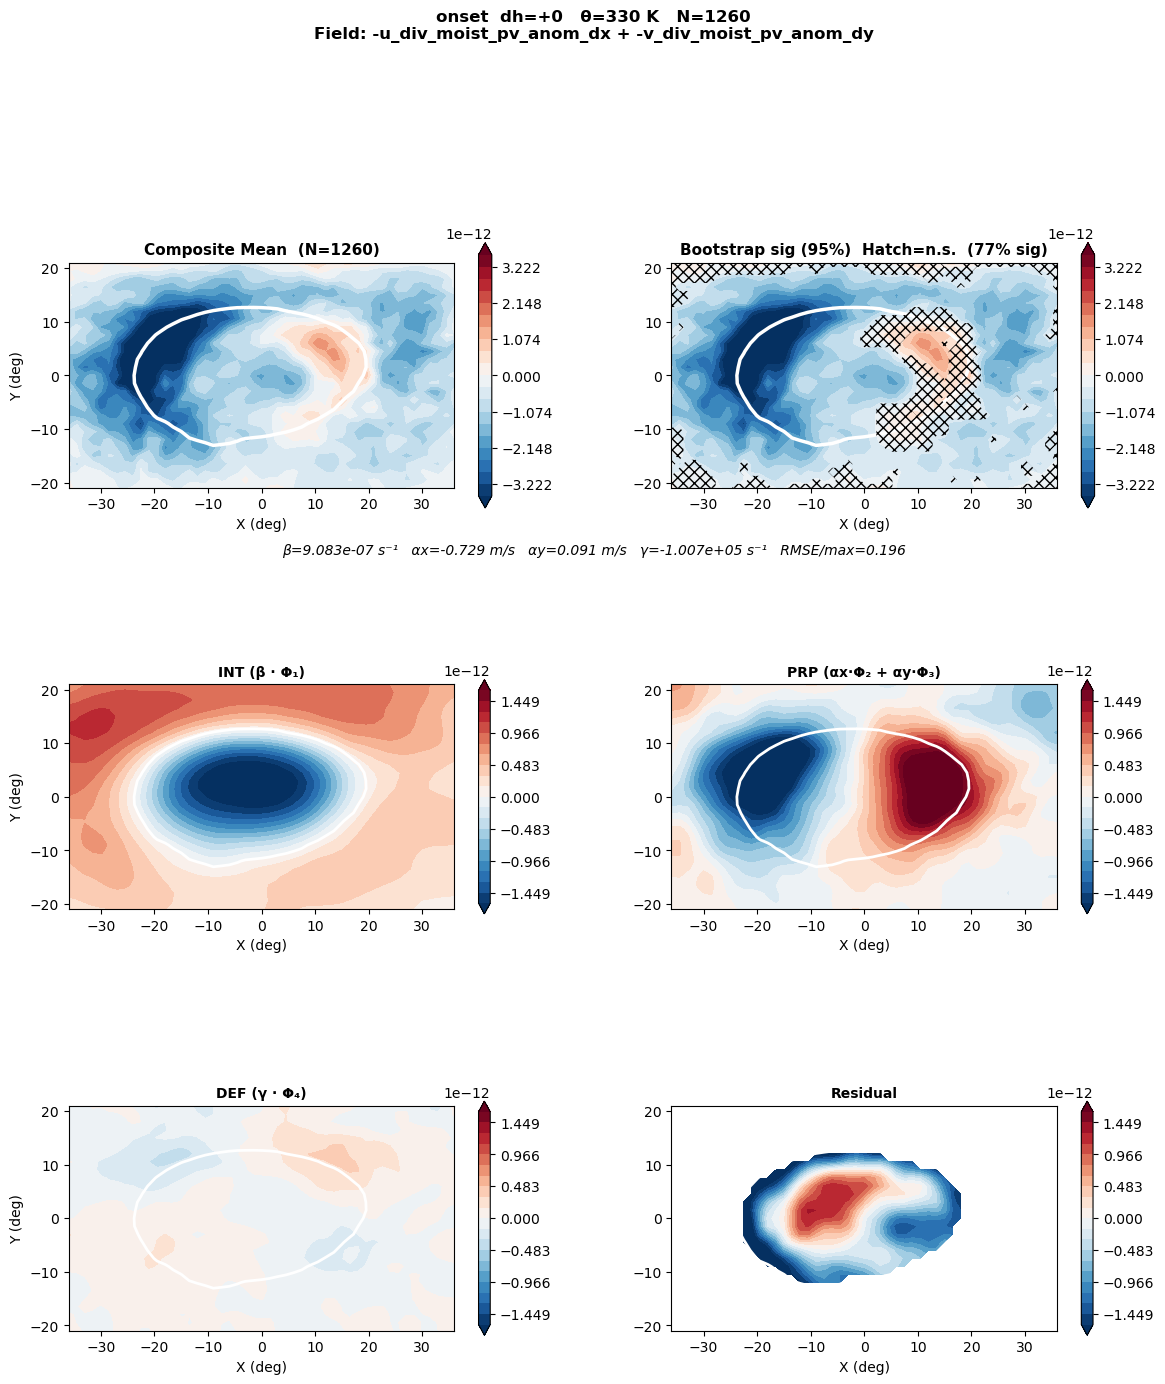

{'beta': 9.082697661895939e-07,
 'ax': -0.7292940651414049,
 'ay': 0.09066658392256802,
 'gamma': -100709.3083220048,
 'gamma_km2': -0.1007093083220048,
 'beta_raw': 9.082697661895939e-13,
 'ax_raw': -7.292940651414049e-13,
 'ay_raw': 9.066658392256802e-14,
 'gamma_raw': -1.007093083220048e-13,
 'prop': array([[ 1.04160215e-13,  9.25693971e-14,  8.37926409e-14, ...,
         -1.08706503e-14,  3.87783722e-14,  6.64416561e-14],
        [ 8.57782684e-14,  1.01943892e-13,  1.10456550e-13, ...,
         -7.15102869e-15,  2.75858891e-14,  6.09014568e-14],
        [ 8.01445140e-14,  1.29418535e-13,  1.52329851e-13, ...,
         -1.93206161e-14, -1.56725450e-14,  2.30226321e-16],
        ...,
        [ 5.58881051e-13,  5.59276167e-13,  5.28161033e-13, ...,
         -7.62553620e-13, -6.61409239e-13, -5.70947432e-13],
        [ 6.33883492e-13,  6.18532047e-13,  5.60641650e-13, ...,
         -6.79965776e-13, -6.32634237e-13, -5.64265397e-13],
        [ 6.96937972e-13,  6.73076426e-13,  5.8257753

In [6]:
# 6-panel: divergent outflow on 330 K with projection
plot_var(["-u_div_moist_pv_anom_dx", "-v_div_moist_pv_anom_dy"],
         dh=0, theta_level=330, projection=True)

Computing bootstrap (N=1260, n_boot=1000, θ=320 K) ...
  Interpolating 1260 events to θ=320 K ...
  93.7% significant at 95%


/tmp/ipykernel_2266529/2997814579.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


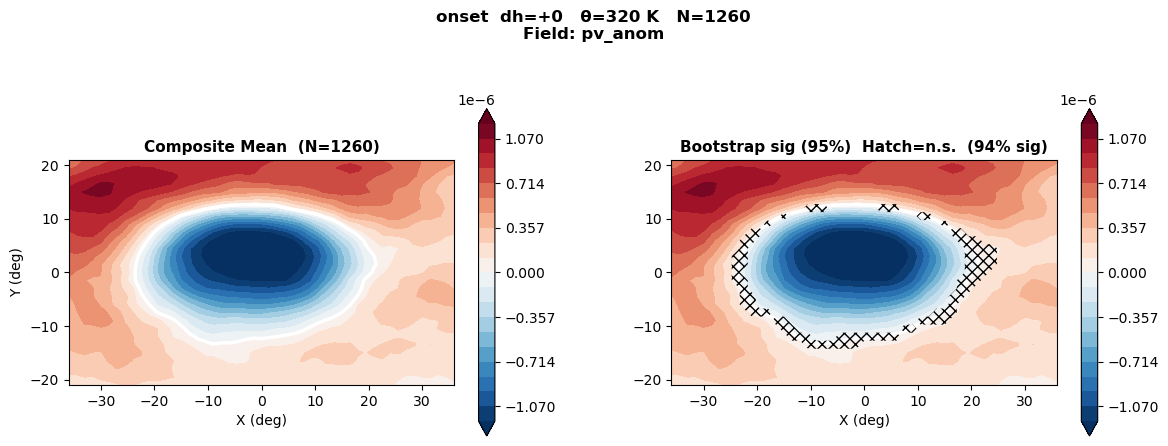

In [7]:
# 2-panel: PV anomaly on 320 K
plot_var(["pv_anom"], dh=0, theta_level=320, projection=False)

Computing bootstrap (N=1260, n_boot=1000, θ=330 K) ...
  Interpolating 1260 events to θ=330 K ...
  55.8% significant at 95%
  Projection (sig_mask=True): β=1.311e-06  αx=16.965  αy=-0.360  γ=-3.033e+06


/tmp/ipykernel_2266529/2997814579.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


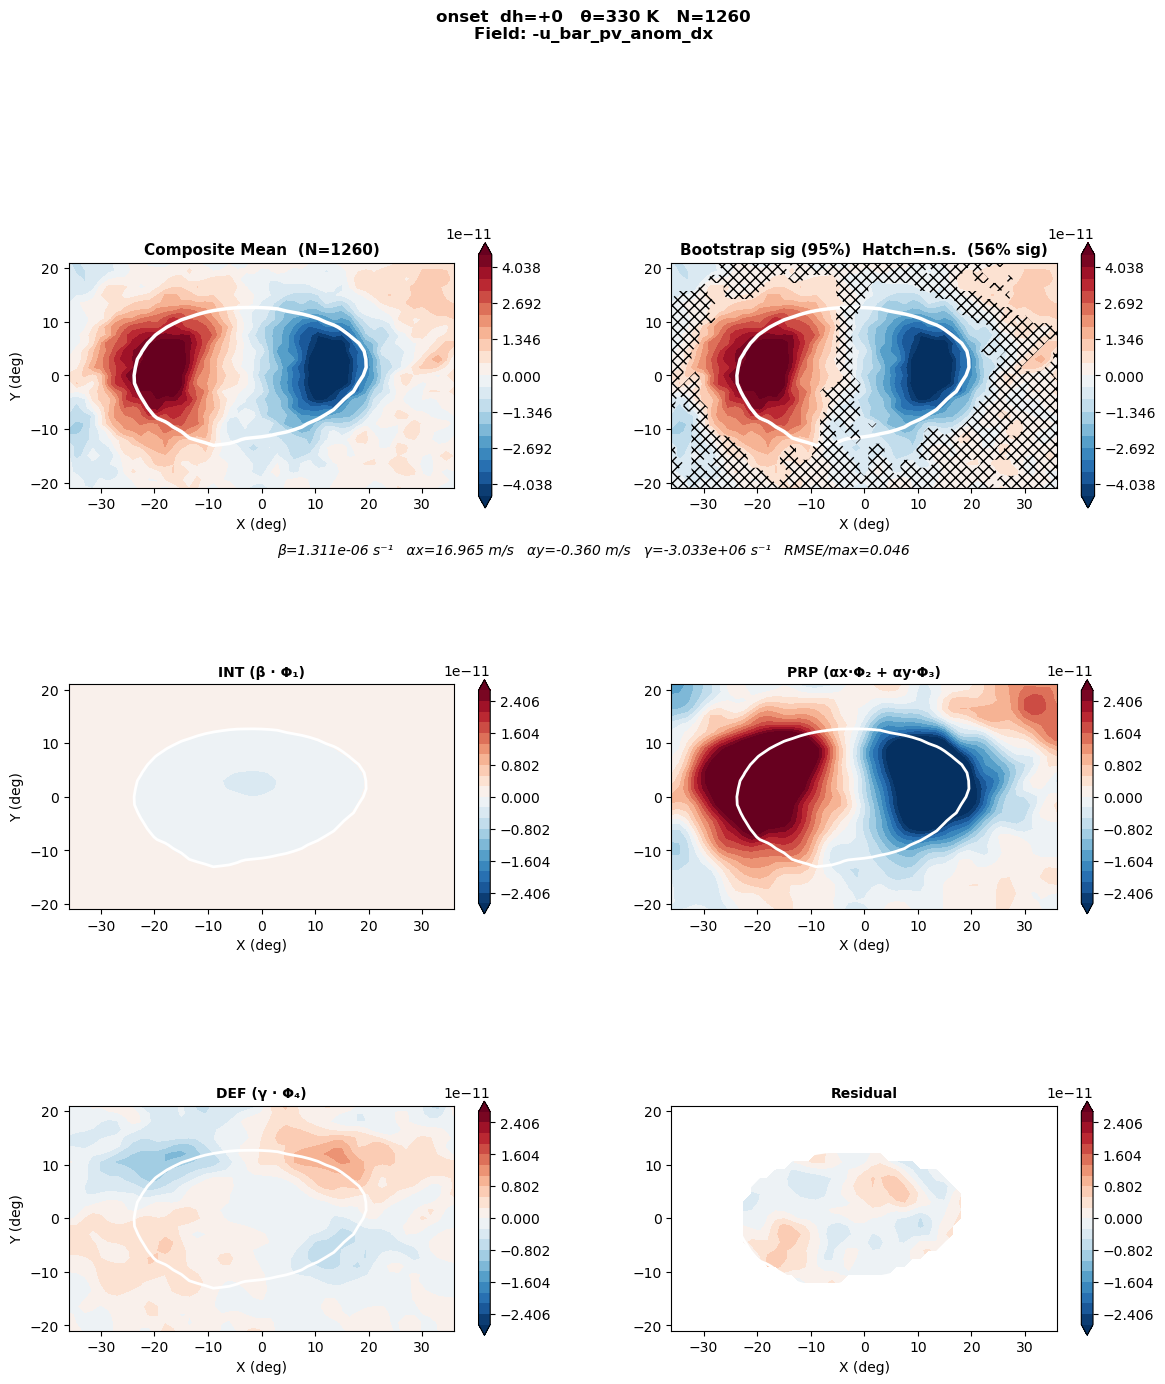

{'beta': 1.3107461720913203e-06,
 'ax': 16.964958140099284,
 'ay': -0.36026453274840703,
 'gamma': -3033314.514252403,
 'gamma_km2': -3.0333145142524027,
 'beta_raw': 1.3107461720913204e-12,
 'ax_raw': 1.6964958140099284e-11,
 'ay_raw': -3.6026453274840705e-13,
 'gamma_raw': -3.0333145142524026e-12,
 'prop': array([[-3.00458492e-12, -2.74551914e-12, -2.56596305e-12, ...,
          4.94954538e-15, -1.12115283e-12, -1.79152089e-12],
        [-2.52756360e-12, -2.94751482e-12, -3.19263285e-12, ...,
         -7.53554053e-14, -8.65802165e-13, -1.62467166e-12],
        [-2.36436548e-12, -3.56722924e-12, -4.12045052e-12, ...,
          1.59819798e-13,  1.42357420e-13, -1.42931504e-13],
        ...,
        [-1.20332367e-11, -1.20764829e-11, -1.13908751e-11, ...,
          1.70946718e-11,  1.46966053e-11,  1.25654807e-11],
        [-1.38512846e-11, -1.35143822e-11, -1.21817489e-11, ...,
          1.53059664e-11,  1.40763169e-11,  1.24297647e-11],
        [-1.54757045e-11, -1.49039462e-11, -1.27

In [8]:
# 6-panel: mean-wind advection on 330 K
plot_var(["-u_bar_pv_anom_dx"], dh=0, theta_level=330, projection=True)

Computing bootstrap (N=1260, n_boot=1000, θ=330 K) ...
  Interpolating 1260 events to θ=330 K ...
  16.3% significant at 95%
  Projection (sig_mask=True): β=2.055e-06  αx=-0.252  αy=0.786  γ=5.257e+05


/tmp/ipykernel_2266529/2997814579.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


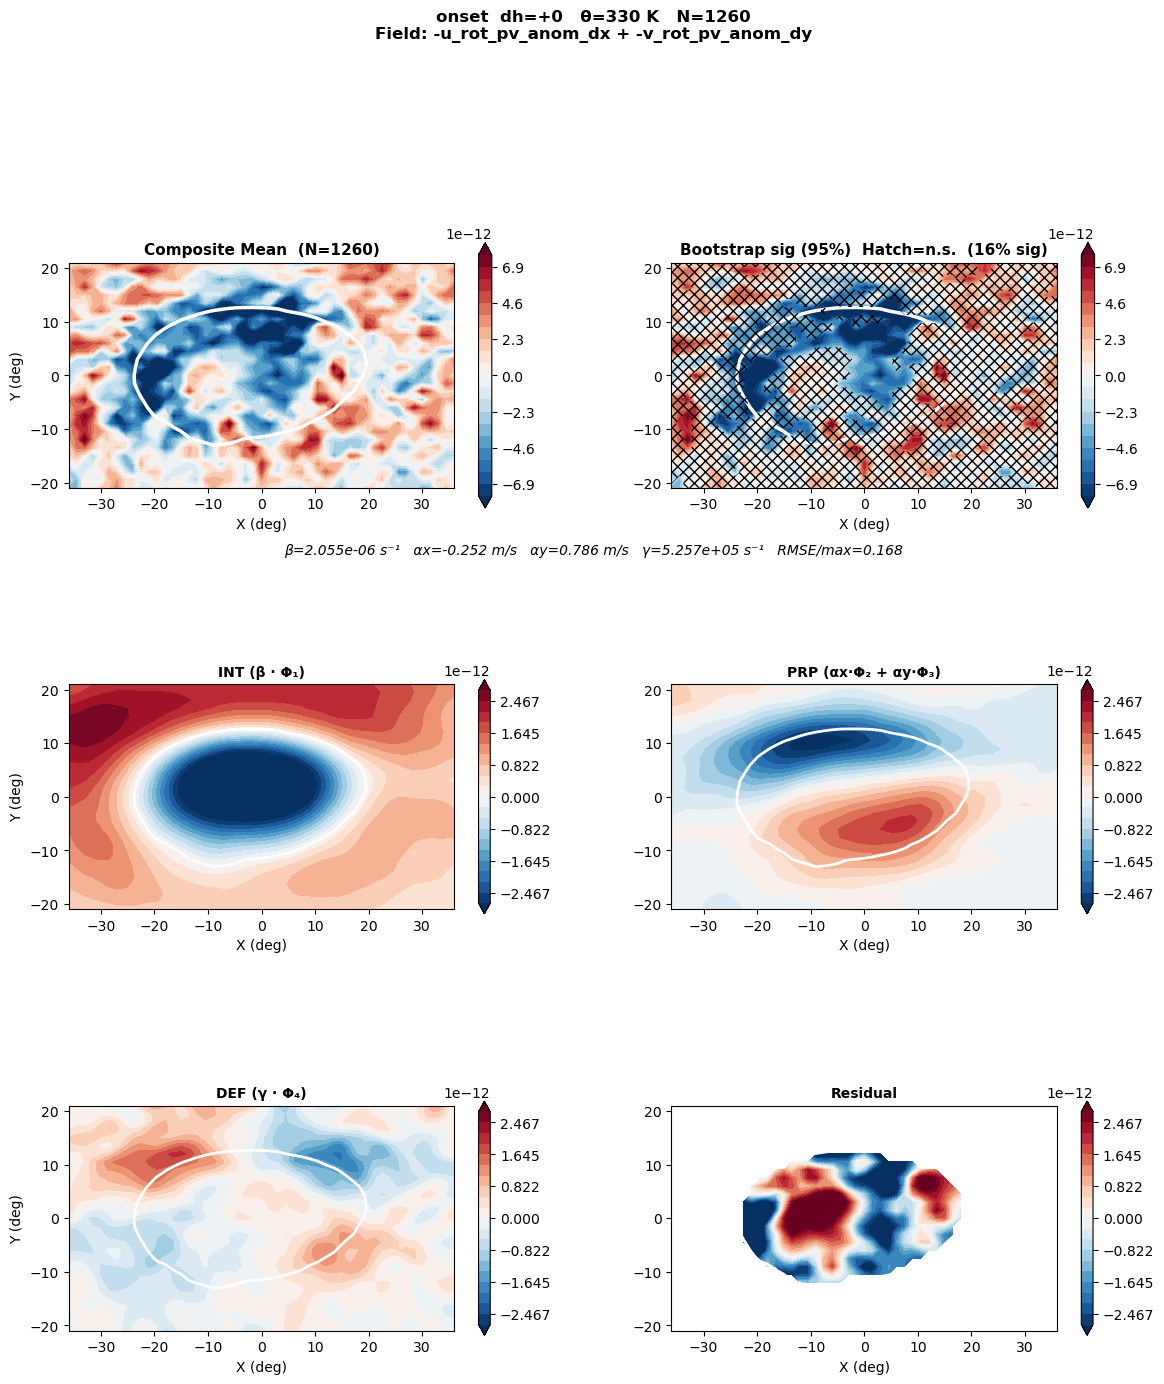

{'beta': 2.054997688485118e-06,
 'ax': -0.25151411396845486,
 'ay': 0.7858424882253933,
 'gamma': 525669.9231082973,
 'gamma_km2': 0.5256699231082973,
 'beta_raw': 2.0549976884851183e-12,
 'ax_raw': -2.5151411396845486e-13,
 'ay_raw': 7.858424882253933e-13,
 'gamma_raw': 5.256699231082973e-13,
 'prop': array([[-2.15018993e-13, -2.23573445e-13, -2.37218952e-13, ...,
         -1.10721832e-13, -8.11549791e-14, -8.32040808e-14],
        [-2.00036180e-13, -2.13404364e-13, -2.30788830e-13, ...,
         -1.06754632e-13, -8.71769508e-14, -6.87308043e-14],
        [-1.88109529e-13, -1.95556279e-13, -1.96394015e-13, ...,
         -1.31625898e-13, -1.01286712e-13, -5.92807719e-14],
        ...,
        [ 6.10212232e-13,  5.95654706e-13,  5.68442765e-13, ...,
         -5.40841884e-13, -5.25475090e-13, -5.05835138e-13],
        [ 6.04439244e-13,  5.90426836e-13,  5.64411652e-13, ...,
         -4.55203908e-13, -4.94374520e-13, -4.95020933e-13],
        [ 5.58169402e-13,  5.57140225e-13,  5.35770584

In [9]:
# 6-panel: rotational eddy advection on 330 K
plot_var(["-u_rot_pv_anom_dx", "-v_rot_pv_anom_dy"],
         dh=0, theta_level=330, projection=True)

Computing bootstrap (N=1260, n_boot=1000, θ=335 K) ...
  Interpolating 1260 events to θ=335 K ...
  23.0% significant at 95%
  Projection (sig_mask=True): β=-7.004e-07  αx=-0.593  αy=0.134  γ=2.733e+05


/tmp/ipykernel_2266529/2997814579.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


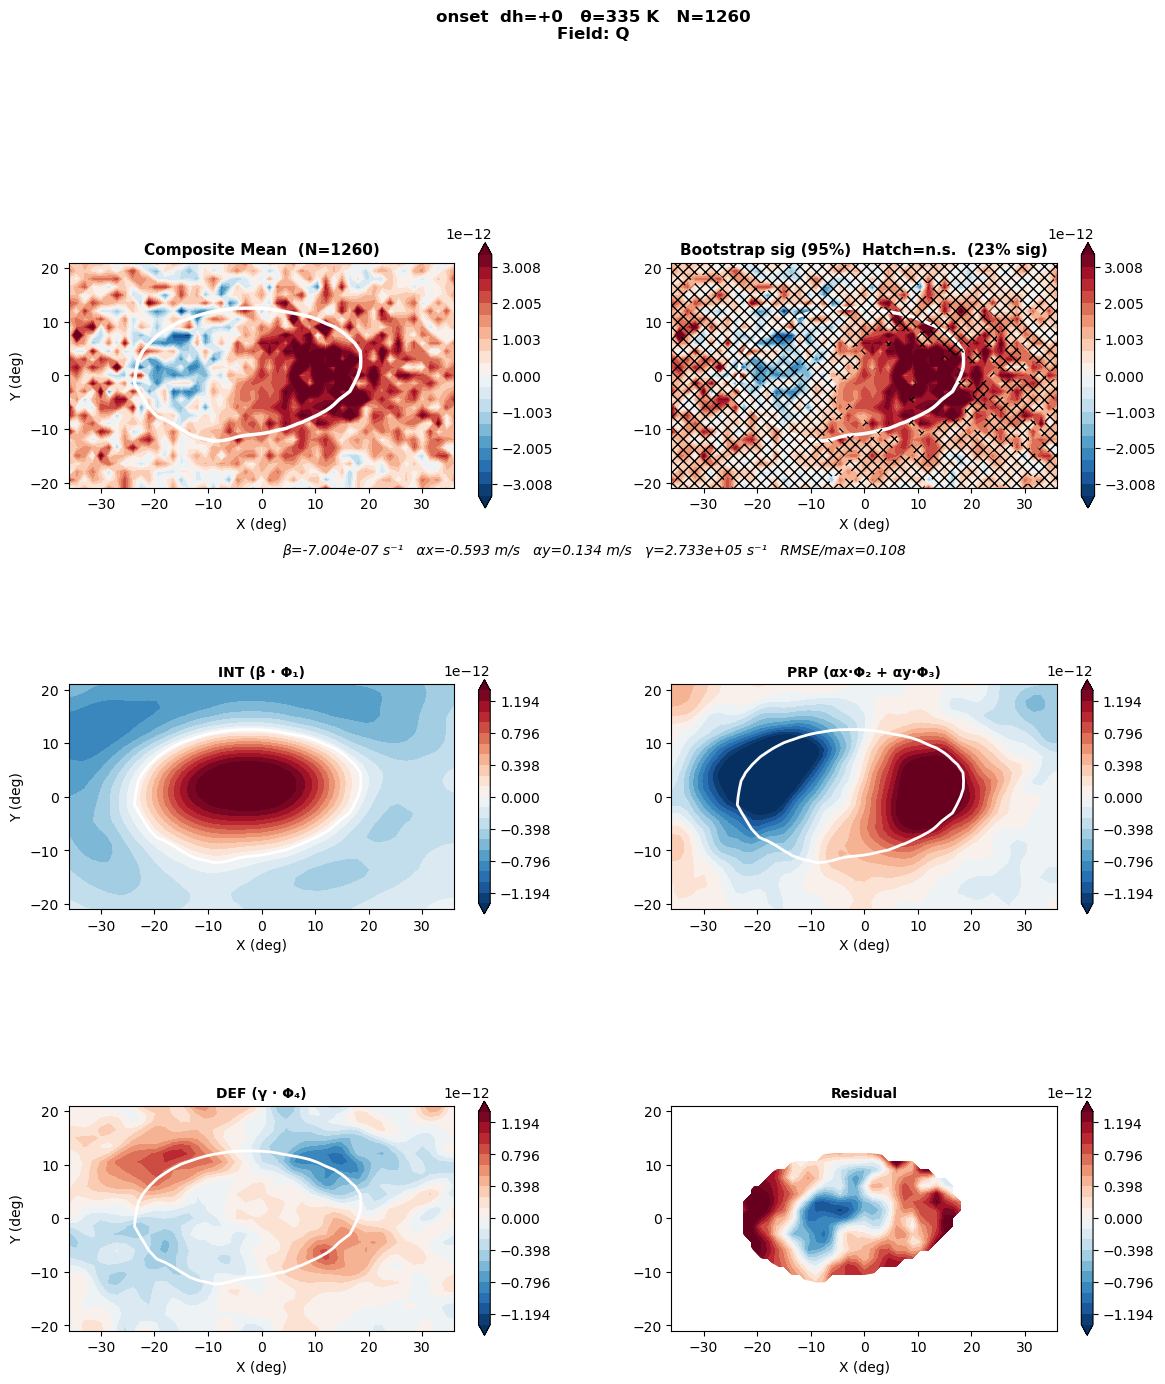

{'beta': -7.003577145226108e-07,
 'ax': -0.5930636854636462,
 'ay': 0.13363628338153175,
 'gamma': 273258.3174798331,
 'gamma_km2': 0.2732583174798331,
 'beta_raw': -7.003577145226107e-13,
 'ax_raw': -5.930636854636461e-13,
 'ay_raw': 1.3363628338153175e-13,
 'gamma_raw': 2.732583174798331e-13,
 'prop': array([[ 1.26506314e-13,  9.19365280e-14,  4.24426453e-14, ...,
         -2.95871355e-14,  1.38483765e-14,  3.60914015e-14],
        [ 1.20016011e-13,  1.19126397e-13,  9.80422178e-14, ...,
         -4.59717517e-14, -7.38147390e-15,  2.65157459e-14],
        [ 1.19630216e-13,  1.53007794e-13,  1.58012770e-13, ...,
         -6.09905451e-14, -4.48302590e-14, -2.06212219e-14],
        ...,
        [ 4.36065959e-13,  4.26623389e-13,  3.98433223e-13, ...,
         -5.69067911e-13, -4.96604360e-13, -4.39794835e-13],
        [ 4.97975206e-13,  4.72562279e-13,  4.28071535e-13, ...,
         -5.15302452e-13, -4.72502238e-13, -4.10733393e-13],
        [ 5.30671800e-13,  5.12861001e-13,  4.5758268

In [10]:
# 6-panel: diabatic Q on 335 K
plot_var(["Q"], dh=0, theta_level=335, projection=True)

Computing bootstrap (N=1260, n_boot=1000, θ=330 K) ...
  Interpolating 1260 events to θ=330 K ...
  74.6% significant at 95%
  Projection (sig_mask=True): β=-3.518e-08  αx=-5.679  αy=0.294  γ=1.081e+06


/tmp/ipykernel_2266529/2997814579.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


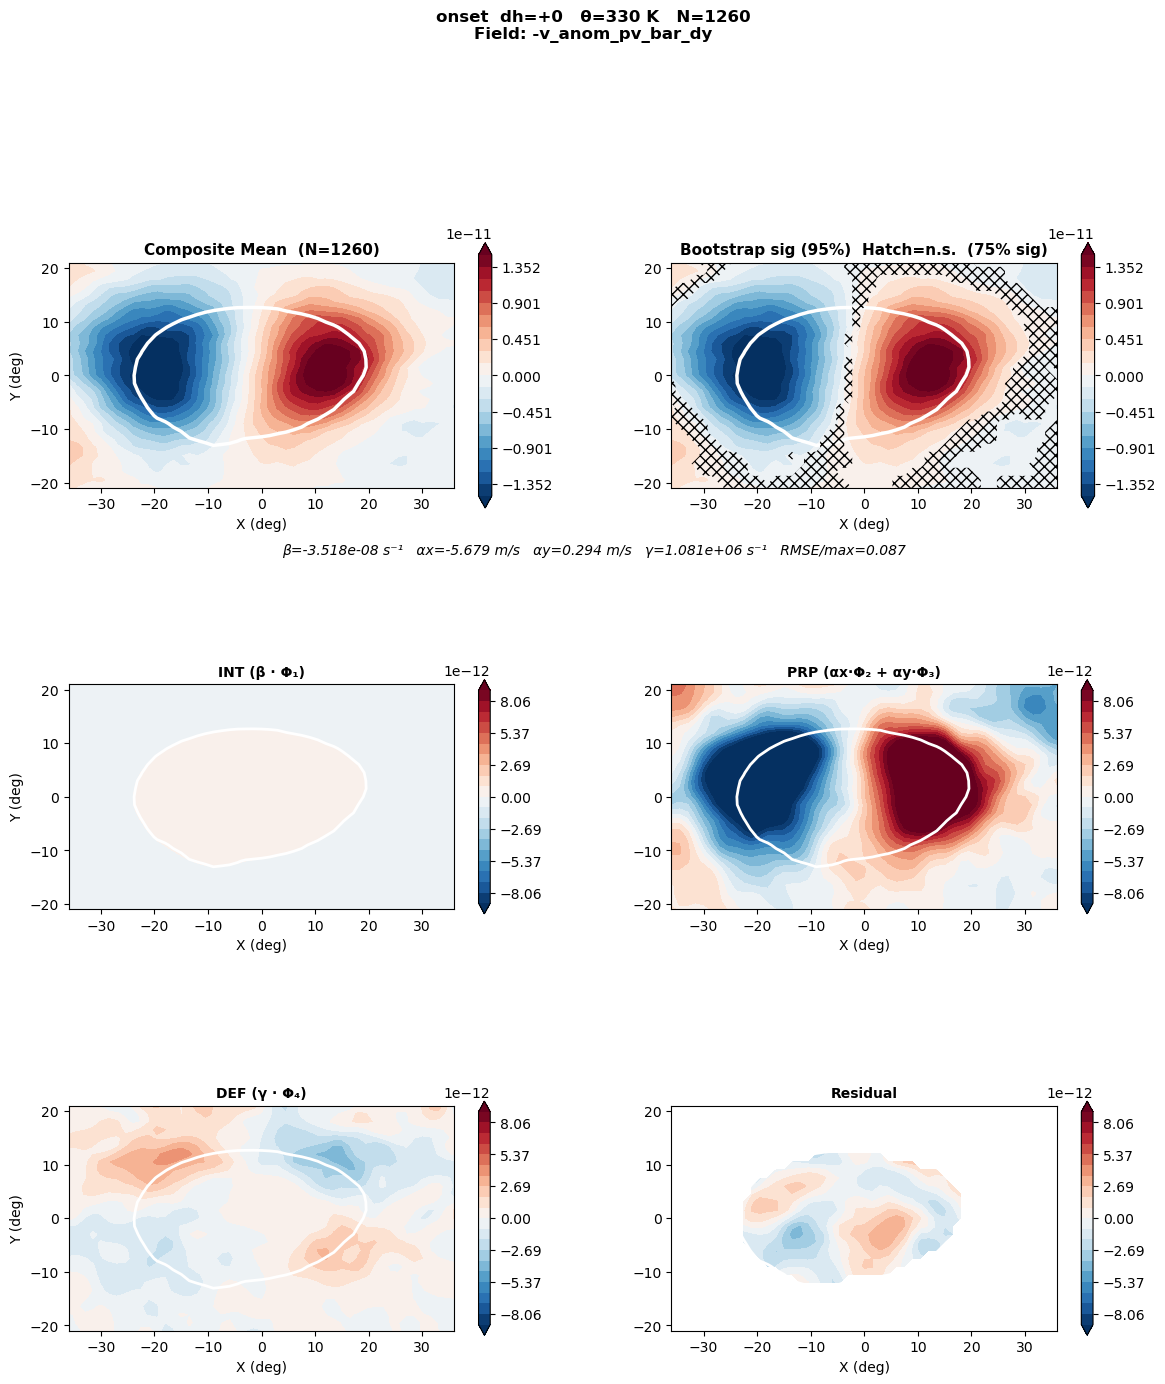

{'beta': -3.518037290913092e-08,
 'ax': -5.678560921344936,
 'ay': 0.2941663463472732,
 'gamma': 1081160.9485905832,
 'gamma_km2': 1.081160948590583,
 'beta_raw': -3.518037290913092e-14,
 'ax_raw': -5.6785609213449366e-12,
 'ay_raw': 2.9416634634727317e-13,
 'gamma_raw': 1.0811609485905831e-12,
 'prop': array([[ 9.47978609e-13,  8.60215061e-13,  7.97670872e-13, ...,
         -2.62640959e-14,  3.53530811e-13,  5.75252429e-13],
        [ 7.93213462e-13,  9.29423181e-13,  1.00679547e-12, ...,
          1.23331765e-15,  2.67561754e-13,  5.23173023e-13],
        [ 7.41777778e-13,  1.13878185e-12,  1.32194740e-12, ...,
         -8.22410093e-14, -6.97063224e-14,  3.41876087e-14],
        ...,
        [ 4.12383253e-12,  4.13492798e-12,  3.90164809e-12, ...,
         -5.78589567e-12, -4.98769691e-12, -4.27701931e-12],
        [ 4.72509678e-12,  4.61032237e-12,  4.16286761e-12, ...,
         -5.17402720e-12, -4.77520076e-12, -4.22963452e-12],
        [ 5.25318153e-12,  5.06345714e-12,  4.3534277

In [11]:
# 6-panel: planetary vorticity advection on 330 K
plot_var(["-v_anom_pv_bar_dy"], dh=0, theta_level=330, projection=True)

Computing bootstrap (N=1260, n_boot=1000, θ=330 K) ...
  Interpolating 1260 events to θ=330 K ...
  35.5% significant at 95%
  Projection (sig_mask=True): β=2.751e-07  αx=-0.880  αy=0.005  γ=9.597e+04


/tmp/ipykernel_2266529/2997814579.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


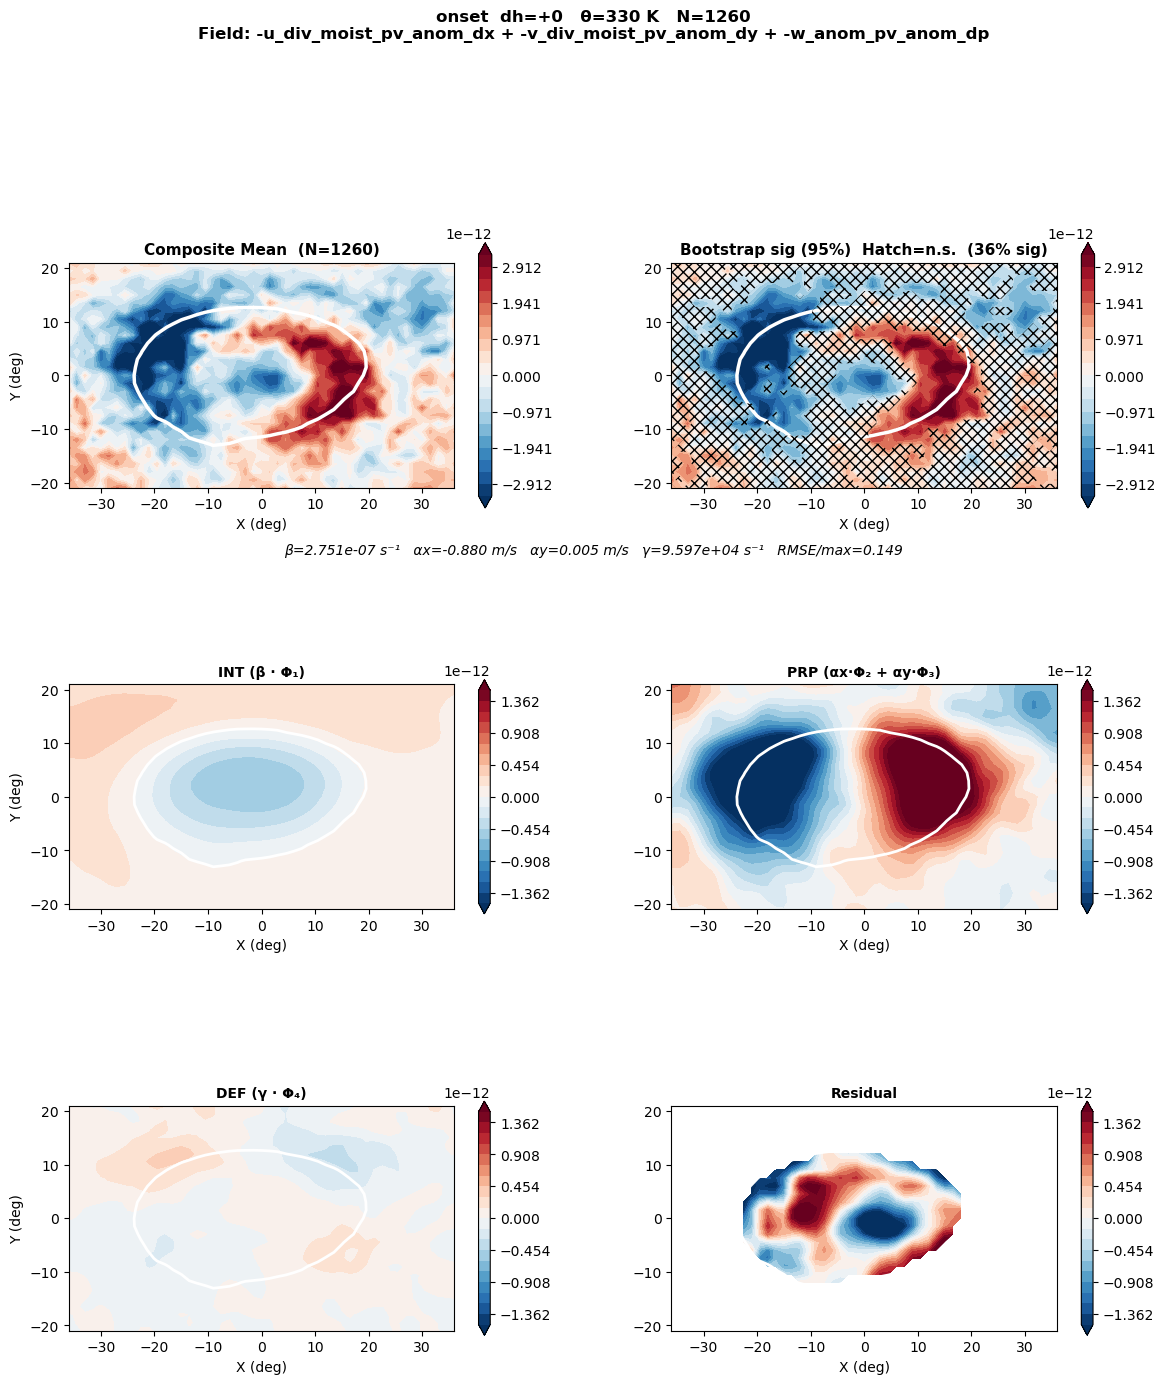

{'beta': 2.7514219587635165e-07,
 'ax': -0.8800284857816508,
 'ay': 0.004888430485449271,
 'gamma': 95974.24114186552,
 'gamma_km2': 0.09597424114186552,
 'beta_raw': 2.7514219587635166e-13,
 'ax_raw': -8.800284857816508e-13,
 'ay_raw': 4.888430485449271e-15,
 'gamma_raw': 9.597424114186552e-14,
 'prop': array([[ 1.60446978e-13,  1.47091720e-13,  1.37971746e-13, ...,
          1.69957459e-15,  5.98866484e-14,  9.48728050e-14],
        [ 1.35312362e-13,  1.57443056e-13,  1.70529757e-13, ...,
          5.81616551e-15,  4.66803034e-14,  8.59181534e-14],
        [ 1.26593088e-13,  1.89436571e-13,  2.18293812e-13, ...,
         -6.00505757e-15, -5.63106202e-15,  8.49991123e-15],
        ...,
        [ 6.16569090e-13,  6.19081139e-13,  5.83817802e-13, ...,
         -8.81675694e-13, -7.56923156e-13, -6.46163305e-13],
        [ 7.11455869e-13,  6.94139068e-13,  6.25121616e-13, ...,
         -7.89934895e-13, -7.25134030e-13, -6.39278894e-13],
        [ 7.96963779e-13,  7.67173107e-13,  6.566063

In [ ]:
# 6-panel: moist-divergent + vertical eddy-eddy on 330 K
plot_var(["-u_div_moist_pv_anom_dx", "-v_div_moist_pv_anom_dy",
          "-w_anom_pv_anom_dp"], dh=0, theta_level=330, projection=True)

## Summary

- `plot_var(var_spec, dh, theta_level, projection)` is the main entry point.
- `var_spec` accepts field names with `-` prefix for negation; lists are summed.
- `theta_level` selects the isentropic surface (e.g. 315–355 K).
- Each event is interpolated from isobaric → isentropic **before** compositing,
  so the bootstrap CI is computed on the per-event θ slices.
- `projection=True` adds the 2×2 INT/PRP/DEF/Residual decomposition
  (6-panel figure); basis from the dh−1 composite on the same θ surface,
  projection uses **only bootstrapped-significant** grid points.
- White contour: PV anomaly = −0.5×10⁻⁶ PVU on the θ surface.